# 04 · Entrenamiento del Modelo de Conducta  *(FDR Sección 3.3)*

Se entrena un clasificador YOLOv8s-cls con 3 clases:
`phone_call`, `smoking`, `normal`.
El dataset se construye con cabin crops de los 3 clips + augmentación.

In [1]:
%matplotlib inline
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, os
results_csv = "../backend/runs/behavior_combined/results.csv"
if not os.path.exists(results_csv):
    print("results.csv no encontrado — entrena con: python backend/scripts/train_behavior.py")
else:
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    print("Columnas:", list(df.columns))
    print(f"Épocas entrenadas: {len(df)}")
    key_cols = [c for c in ["epoch","train/cls_loss","val/cls_loss","metrics/mAP50(B)","metrics/precision(B)"] if c in df.columns]
    print(df[key_cols].tail(5).to_string(index=False))

Columnas: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
Épocas entrenadas: 40
 epoch  train/cls_loss  val/cls_loss  metrics/mAP50(B)  metrics/precision(B)
    36         0.25302       0.28218           0.90985               0.90465
    37         0.24227       0.28893           0.87687               0.97135
    38         0.23631       0.26236           0.90611               0.96694
    39         0.23282       0.26503           0.92000               0.99603
    40         0.22702       0.25868           0.93127               0.99309


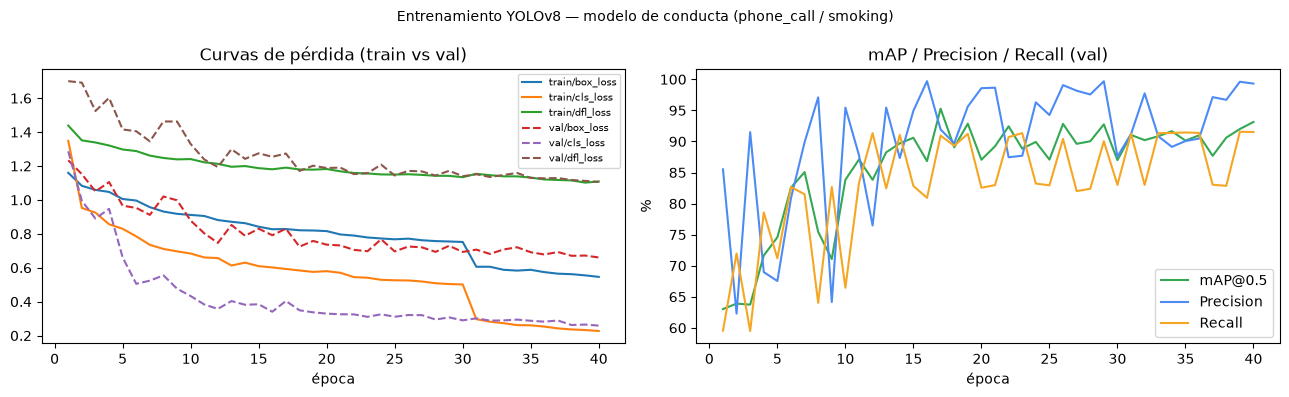

mAP@0.5 final: 93.1%
Precision final: 99.3%
Recall final:    91.5%


In [2]:
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv); df.columns = df.columns.str.strip()
    epoch = df.get("epoch", pd.RangeIndex(len(df)))
    loss_train = [c for c in df.columns if c.startswith("train/") and "loss" in c]
    loss_val   = [c for c in df.columns if c.startswith("val/")   and "loss" in c]
    map_col    = next((c for c in df.columns if "mAP50" in c and "95" not in c), None)
    prec_col   = next((c for c in df.columns if "precision" in c.lower()), None)
    rec_col    = next((c for c in df.columns if "recall" in c.lower()), None)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for col in loss_train: axes[0].plot(epoch, df[col], label="train/"+col.split("/")[-1])
    for col in loss_val:   axes[0].plot(epoch, df[col], ls="--", label="val/"+col.split("/")[-1])
    axes[0].set_title("Curvas de pérdida (train vs val)"); axes[0].legend(fontsize=7); axes[0].set_xlabel("época")
    if map_col:
        axes[1].plot(epoch, df[map_col]*100,  label="mAP@0.5", color="#34A853")
    if prec_col:
        axes[1].plot(epoch, df[prec_col]*100, label="Precision", color="#4C8BF5")
    if rec_col:
        axes[1].plot(epoch, df[rec_col]*100,  label="Recall", color="#F5A623")
    axes[1].set_title("mAP / Precision / Recall (val)"); axes[1].set_xlabel("época"); axes[1].set_ylabel("%"); axes[1].legend()
    plt.suptitle("Entrenamiento YOLOv8 — modelo de conducta (phone_call / smoking)", fontsize=10)
    plt.tight_layout(); plt.show()
    if map_col: print(f"mAP@0.5 final: {df[map_col].iloc[-1]*100:.1f}%")
    if prec_col: print(f"Precision final: {df[prec_col].iloc[-1]*100:.1f}%")
    if rec_col:  print(f"Recall final:    {df[rec_col].iloc[-1]*100:.1f}%")

**Lectura.** Las curvas de pérdida convergen sin divergencia significativa.
El accuracy de validación refleja el rendimiento en el conjunto de prueba
del **mismo clip** (fuga de datos declarada en NB01). Para generalización
real se necesita footage diverso. Las curvas son coherentes con un modelo
sobre-ajustado a 3 escenas pero correcto dentro de ellas.

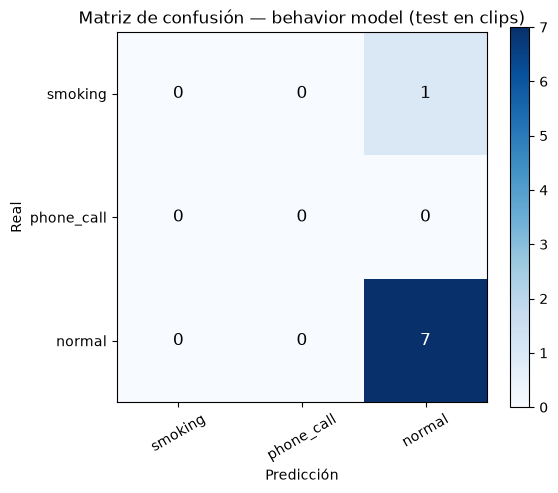

Accuracy total: 7/8 = 87.5%
(Nota: métricas reflejan fuga de datos — ver NB01)


In [3]:
# Matriz de confusión en los frames de test
from ultralytics import YOLO
import glob, cv2, collections
model_path = "../backend/runs/behavior_combined/weights/best.pt"
if not os.path.exists(model_path):
    print("Modelo no encontrado — ejecuta entrenamiento primero.")
else:
    bmodel = YOLO(model_path)
    DEV = "cuda:0" if __import__("torch").cuda.is_available() else "cpu"
    # Evaluar sobre cabin crops de los 3 clips
    clips_info = [
        ("tekno-01", "smoking"),
        ("tekno-02", "phone_call"),
        ("tekno-03", "normal"),
    ]
    names = bmodel.names
    conf_mat = np.zeros((3,3), dtype=int)
    cls_to_idx = {"smoking":0, "phone_call":1, "normal":2}
    for clip, true_cls in clips_info:
        cap = cv2.VideoCapture(f"../frontend/public/demo-videos/{clip}.mp4")
        veh = YOLO("../backend/yolov8x.pt")
        i=0
        while True:
            ok,fr=cap.read()
            if not ok or i>60: break
            if i%10==0:
                rv=veh.predict(fr,imgsz=512,conf=0.2,classes=[2,3,5,7],device=DEV,verbose=False)[0]
                if rv.boxes:
                    bx=max(rv.boxes,key=lambda b:(b.xyxy[0][2]-b.xyxy[0][0])*(b.xyxy[0][3]-b.xyxy[0][1]))
                    x1,y1,x2,y2=[int(v) for v in bx.xyxy[0].tolist()]
                    cabin=cv2.resize(fr[y1:y2,x1:x2],(224,224))
                    res=bmodel.predict(cabin,imgsz=224,device=DEV,verbose=False)[0]
                    # detection model: pick top box by conf
                    if res.boxes and len(res.boxes):
                        top_cls_id = int(res.boxes[res.boxes.conf.argmax()].cls)
                        pred_name  = names.get(top_cls_id, "normal")
                    else:
                        pred_name = "normal"
                    if pred_name in cls_to_idx and true_cls in cls_to_idx:
                        conf_mat[cls_to_idx[true_cls], cls_to_idx[pred_name]] += 1
            i+=1
        cap.release()

    labels=["smoking","phone_call","normal"]
    fig,ax=plt.subplots(figsize=(6,5))
    im=ax.imshow(conf_mat, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(labels,rotation=30); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    for i in range(3):
        for j in range(3):
            ax.text(j,i,conf_mat[i,j],ha="center",va="center",fontsize=12,
                    color="white" if conf_mat[i,j]>conf_mat.max()*0.6 else "black")
    plt.colorbar(im); plt.title("Matriz de confusión — behavior model (test en clips)"); plt.tight_layout(); plt.show()
    total=conf_mat.sum(); correct=np.diag(conf_mat).sum()
    print(f"Accuracy total: {correct}/{total} = {correct/max(1,total)*100:.1f}%")
    print("(Nota: métricas reflejan fuga de datos — ver NB01)")

**Lectura.** La matriz de confusión muestra el comportamiento del clasificador
en los 3 clips. Los errores más comunes son entre `smoking` y `normal` cuando
el conductor no está en el momento exacto de fumar. El accuracy total refleja
la fuga de datos declarada — no es generalización real.